In [2]:
import re
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import math

## Limpieza excel para no afectar formato devido a objetos json

In [3]:
def clean_parse_file():
	input_file = "./steam-dataset/games.csv"
	output_file = "./steam-dataset/games_fixed.csv"

	# GPT me dió el regex para limpiar el excel y poder leerlo más facilmente con 
	# pandas
	pattern = re.compile(r',(?=[^{}]*\})') 

	with open(input_file, "r", encoding="utf-8") as infile, \
		open(output_file, "w", encoding="utf-8") as outfile:

		for line in infile:
			line = pattern.sub("|", line)
			outfile.write(line)

## Leer archivos .csv en objeto pandas

In [4]:
df_games = pd.read_csv("./steam-dataset/games_fixed_clean.csv", encoding="ISO-8859-1", na_values="\\N")
print(df_games.head())

   app_id                       name release_date  is_free  \
0      10             Counter-Strike   01/11/2000        0   
1      20      Team Fortress Classic   01/04/1999        0   
2      30              Day of Defeat   01/05/2003        0   
3      40         Deathmatch Classic   01/06/2001        0   
4      50  Half-Life: Opposing Force   01/11/1999        0   

                                      price_overview  \
0  {\final\": 819| \"initial\": 819| \"currency\"...   
1  {\final\": 499| \"initial\": 499| \"currency\"...   
2  {\final\": 499| \"initial\": 499| \"currency\"...   
3  {\final\": 499| \"initial\": 499| \"currency\"...   
4  {\final\": 499| \"initial\": 499| \"currency\"...   

                                           languages  type  
0  English<strong>*</strong>, French<strong>*</st...  game  
1  English, French, German, Italian, Spanish - Sp...  game  
2  English, French, German, Italian, Spanish - Spain  game  
3  English, French, German, Italian, Spanish -

## Función auxiliar para detectar la calidad del dataset y columnas con una cantidad considerable de datos faltantes

In [5]:
def see_nan_values(df):
	df.info()
	nan_values = df.isnull().sum()
	print(nan_values / len(df) * 100)

	print(f"Lenght of dataset: {len(df)}")

In [6]:
see_nan_values(df_games)

<class 'pandas.DataFrame'>
RangeIndex: 140082 entries, 0 to 140081
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   app_id          140082 non-null  int64
 1   name            140062 non-null  str  
 2   release_date    111564 non-null  str  
 3   is_free         140082 non-null  int64
 4   price_overview  76334 non-null   str  
 5   languages       132853 non-null  str  
 6   type            140082 non-null  str  
dtypes: int64(2), str(5)
memory usage: 7.5 MB
app_id             0.000000
name               0.014277
release_date      20.358076
is_free            0.000000
price_overview    45.507631
languages          5.160549
type               0.000000
dtype: float64
Lenght of dataset: 140082


Ya que la cantidad de valores vaciós en precio es considerable y un dato que quiero analizar decidí tumbar las instancias que no contaban con este valor.

In [7]:
# Test remove empty price values
df_games.dropna(subset=["price_overview"], inplace=True)

In [8]:
nan_values = df_games.isnull().sum()
print(nan_values / len(df_games) * 100)

print(f"Lenght of dataset: {len(df_games)}")

app_id            0.000000
name              0.002620
release_date      0.972044
is_free           0.000000
price_overview    0.000000
languages         0.120523
type              0.000000
dtype: float64
Lenght of dataset: 76334


Debido a que el precio viene en una columna en formato JSON tuve que utilizar regex para extraer el precio y moneda de las instancias para poder analizarlo correctamente. De esta manera extraje el precio en dos columnas con las que puedo trabajar y analizar.

In [9]:
# IA para extraer la información con regex
s = df_games["price_overview"].astype("string")

df_games["price"] = pd.to_numeric(
	s.str.extract(r'final\\?"?\s*[:|]\s*(\d+(?:\.\d+)?)', expand=False)
) / 100

df_games["currency"] = s.str.extract(
	r'currency\\?"?\s*[:|]\s*\\?"?([A-Z]{3})',
	expand=False
)

df_games

,app_id,name,release_date,is_free,price_overview,languages,type,price,currency
0,10,Counter-Strike,01/11/2000,0,"{\final\"": 819| \""initial\"": 819| \""currency\""...","English<strong>*</strong>, French<strong>*</st...",game,8.19,EUR
1,20,Team Fortress Classic,01/04/1999,0,"{\final\"": 499| \""initial\"": 499| \""currency\""...","English, French, German, Italian, Spanish - Sp...",game,4.99,EUR
2,30,Day of Defeat,01/05/2003,0,"{\final\"": 499| \""initial\"": 499| \""currency\""...","English, French, German, Italian, Spanish - Spain",game,4.99,EUR
3,40,Deathmatch Classic,01/06/2001,0,"{\final\"": 499| \""initial\"": 499| \""currency\""...","English, French, German, Italian, Spanish - Sp...",game,4.99,EUR
4,50,Half-Life: Opposing Force,01/11/1999,0,"{\final\"": 499| \""initial\"": 499| \""currency\""...","English, French, German, Korean",game,4.99,EUR
...,...,...,...,...,...,...,...,...,...
139300,3263590,Mazzle Halloween,17/10/2024,0,"{\final\"": 119| \""initial\"": 199| \""currency\""...","English<strong>*</strong>, French<strong>*</st...",game,1.19,EUR
139314,3263950,Sex Summer Camp,18/10/2024,0,"{\final\"": 412| \""initial\"": 589| \""currency\""...",English<strong>*</strong><br><strong>*</strong...,game,4.12,EUR
139425,3266470,Futanari Sex Adventures - Episode 5,17/10/2024,0,"{\final\"": 399| \""initial\"": 499| \""currency\""...",English,game,3.99,EUR
139822,3278740,NEURO,11/10/2024,0,"{\final\"": 975| \""initial\"": 975| \""currency\""...","English<strong>*</strong>, Russian<strong>*</s...",game,9.75,EUR


In [10]:
df_games.drop(columns=["price_overview", "languages", "type"], inplace=True)
see_nan_values(df_games)

<class 'pandas.DataFrame'>
Index: 76334 entries, 0 to 139931
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   app_id        76334 non-null  int64  
 1   name          76332 non-null  str    
 2   release_date  75592 non-null  str    
 3   is_free       76334 non-null  int64  
 4   price         76334 non-null  Float64
 5   currency      76334 non-null  string 
dtypes: Float64(1), int64(2), str(2), string(1)
memory usage: 4.1 MB
app_id          0.000000
name            0.002620
release_date    0.972044
is_free         0.000000
price           0.000000
currency        0.000000
dtype: float64
Lenght of dataset: 76334


## Análisis genérica de la información

currency
EUR    75623
USD      482
GBP       46
RUB       31
CAD       20
ILS       18
BRL       12
KRW        9
PLN        9
AUD        9
CNY        9
MXN        8
UAH        7
TWD        7
SGD        6
PHP        5
INR        4
IDR        4
JPY        4
HKD        4
SAR        3
KWD        3
KZT        2
MYR        2
PEN        1
COP        1
NZD        1
THB        1
AED        1
VND        1
NOK        1
Name: count, dtype: Int64


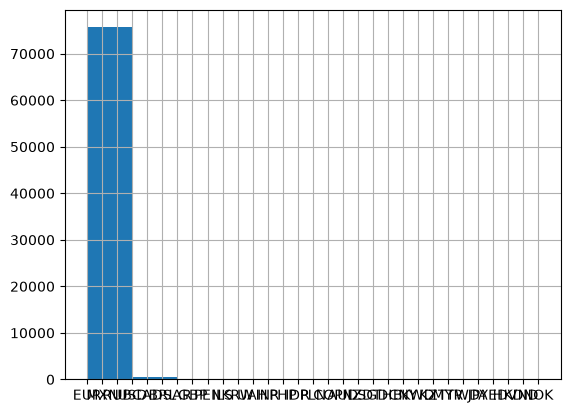

In [11]:
df_games['currency'].hist()
unique_curr = df_games['currency'].value_counts()
print(unique_curr)


## Hay juegos con monedas diferentes

Por ello, decidí normalizar los precios de los juegos a Euros, ya que es la moneda más común en el dataset. 

Archivo descargado el 22 de agosto, 2026
https://www.ecb.europa.eu/stats/eurofxref/eurofxref-hist.zip 

In [12]:
from currency_converter import CurrencyConverter
c = CurrencyConverter('./eurofxref-hist.csv')

In [13]:
df_games.info()

<class 'pandas.DataFrame'>
Index: 76334 entries, 0 to 139931
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   app_id        76334 non-null  int64  
 1   name          76332 non-null  str    
 2   release_date  75592 non-null  str    
 3   is_free       76334 non-null  int64  
 4   price         76334 non-null  Float64
 5   currency      76334 non-null  string 
dtypes: Float64(1), int64(2), str(2), string(1)
memory usage: 4.1 MB


In [14]:
# Missing rates
df_games = df_games.replace('SAR', 'ZAR')

rates = {
	currency: c.convert(1, currency, 'EUR')
	for currency in c.currencies
}

rates['PEN'] = 0.26
rates['UAH'] = 0.019
rates['COP'] = 0.00028
rates['KWD'] = 2.78
rates['KZT'] = 0.0019
rates['TWD'] = 0.027
rates['AED'] = 0.23
rates['VND'] = 0.000033
df_games['prices_eur'] = df_games['price'] * df_games['currency'].map(rates)
see_nan_values(df_games)

<class 'pandas.DataFrame'>
Index: 76334 entries, 0 to 139931
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   app_id        76334 non-null  int64  
 1   name          76332 non-null  str    
 2   release_date  75592 non-null  str    
 3   is_free       76334 non-null  int64  
 4   price         76334 non-null  Float64
 5   currency      76334 non-null  string 
 6   prices_eur    76334 non-null  Float64
dtypes: Float64(2), int64(2), str(2), string(1)
memory usage: 4.8 MB
app_id          0.000000
name            0.002620
release_date    0.972044
is_free         0.000000
price           0.000000
currency        0.000000
prices_eur      0.000000
dtype: float64
Lenght of dataset: 76334


# DF Games está limpio y listo, leer los siguientes archivos y unión de la información

76334
<class 'pandas.DataFrame'>
Index: 76334 entries, 0 to 139931
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   app_id        76334 non-null  int64  
 1   name          76332 non-null  str    
 2   release_date  75592 non-null  str    
 3   is_free       76334 non-null  int64  
 4   price         76334 non-null  Float64
 5   currency      76334 non-null  string 
 6   prices_eur    76334 non-null  Float64
dtypes: Float64(2), int64(2), str(2), string(1)
memory usage: 4.8 MB
0    8.19
1    4.99
2    4.99
3    4.99
4    4.99
Name: prices_eur, dtype: Float64
Cantidad de juegos con la categoría gratis is_free
0    76332
1        2
Name: count, dtype: int64
Min 0.0
Max 999.0
Quantil 0.99:  48.99


<Axes: >

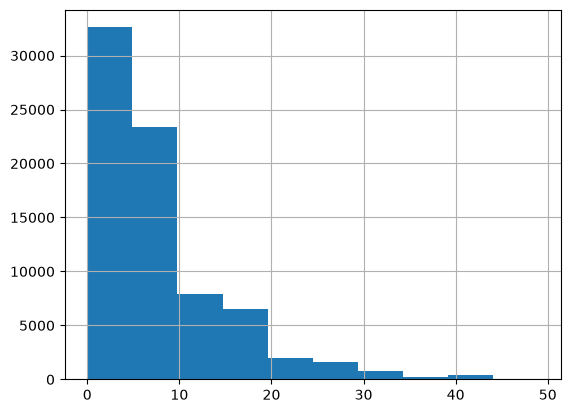

In [15]:
import seaborn as sns

print(len(df_games))
df_games.info()
df_games.drop(columns=["price", "currency", 'is_free'])

print(df_games['prices_eur'].head())
print("Cantidad de juegos con la categoría gratis", df_games['is_free'].value_counts())
print('Min', df_games['prices_eur'].min())
print('Max', df_games['prices_eur'].max())
print('Quantil 0.99: ', df_games["prices_eur"].quantile(0.99))

df_games[df_games["prices_eur"] < df_games["prices_eur"].quantile(0.99)]['prices_eur'].hist()


In [16]:
def one_hot_encoding(df, column): 
	# https://www.geeksforgeeks.org/machine-learning/one-hot-encoding-from-a-pandas-column-containing-a-list/
  for category in df[column].unique():
	  df[category] = df[column].apply(lambda x: 1 if category in x else 0)

  # Drop the original column
  return df.drop(column, axis=1)

In [17]:
df_categories = pd.read_csv('./steam-dataset/categories.csv', na_values="\\N")
df_genres = pd.read_csv("./steam-dataset/genres.csv", na_values="\\N")
df_reviews = pd.read_csv("./steam-dataset/reviews.csv", na_values="\\N")
df_insights = pd.read_csv("./steam-dataset/steamspy_insights.csv", encoding="ISO-8859-1", na_values="\\N")
df_tags = pd.read_csv("./steam-dataset/tags.csv", na_values="\\N")

In [18]:
# See if there is information missing
print("categories:")
see_nan_values(df_categories) # Clean
print(df_categories.value_counts())
print(len(df_categories["category"].unique()))


categories:
<class 'pandas.DataFrame'>
RangeIndex: 522582 entries, 0 to 522581
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   app_id    522582 non-null  int64
 1   category  522582 non-null  str  
dtypes: int64(1), str(1)
memory usage: 8.0 MB
app_id      0.0
category    0.0
dtype: float64
Lenght of dataset: 522582
app_id   category               
10       Family Sharing             1
         Multi-player               1
         Online PvP                 1
         PvP                        1
         Shared/Split Screen PvP    1
                                   ..
3298610  Game demo                  1
3298710  Full controller support    1
         Single-player              1
         Steam Achievements         1
         Steam Cloud                1
Name: count, Length: 522582, dtype: int64
315


In [19]:
print("genres:")
see_nan_values(df_genres) # Clean
df_genres["genre"].value_counts()

genres:
<class 'pandas.DataFrame'>
RangeIndex: 353339 entries, 0 to 353338
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   app_id  353339 non-null  int64
 1   genre   353339 non-null  str  
dtypes: int64(1), str(1)
memory usage: 5.4 MB
app_id    0.0
genre     0.0
dtype: float64
Lenght of dataset: 353339


genre
Indie                86425
Action               52753
Adventure            50835
Casual               48633
Simulation           24916
                     ...  
Passatempo               1
Course automobile        1
Estratégia               1
Grátis para Jogar        1
Simulação                1
Name: count, Length: 121, dtype: int64

In [20]:
print("reviews:")
df_reviews.dropna(thresh=1)
see_nan_values(df_reviews)
df_reviews_important = df_reviews.drop(['metacritic_score', 'reviews', 'recommendations', 'steamspy_user_score', 'steamspy_score_rank', 'steamspy_positive', 'steamspy_negative'], axis=1)
print(df_reviews_important.columns)
df_reviews_important

reviews:
<class 'pandas.DataFrame'>
RangeIndex: 140082 entries, 0 to 140081
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   app_id                    140082 non-null  int64  
 1   review_score              140077 non-null  float64
 2   review_score_description  140077 non-null  str    
 3   positive                  140077 non-null  float64
 4   negative                  140077 non-null  float64
 5   total                     140077 non-null  float64
 6   metacritic_score          4745 non-null    float64
 7   reviews                   11764 non-null   str    
 8   recommendations           17296 non-null   float64
 9   steamspy_user_score       140077 non-null  float64
 10  steamspy_score_rank       51 non-null      float64
 11  steamspy_positive         140077 non-null  float64
 12  steamspy_negative         140077 non-null  float64
dtypes: float64(10), int64(1), str(2)
memory usage:

,app_id,review_score,review_score_description,positive,negative,total
0,10,9.0,Overwhelmingly Positive,235403.0,6207.0,241610.0
1,20,8.0,Very Positive,7315.0,1094.0,8409.0
2,30,8.0,Very Positive,6249.0,672.0,6921.0
3,40,8.0,Very Positive,2542.0,524.0,3066.0
4,50,9.0,Overwhelmingly Positive,22263.0,1111.0,23374.0
...,...,...,...,...,...,...
140077,3297700,0.0,No user reviews,0.0,0.0,0.0
140078,3297890,0.0,No user reviews,0.0,1.0,1.0
140079,3298020,0.0,No user reviews,0.0,0.0,0.0
140080,3298610,0.0,No user reviews,0.0,0.0,0.0


In [21]:
df_reviews_important.info()
see_nan_values(df_reviews_important)
print(df_reviews_important['review_score_description'].value_counts())
categories = df_reviews_important['review_score_description'].unique()
print("Categorías: ", categories)
df_reviews_important.dropna(subset=['review_score_description'], inplace=True)
categories = df_reviews_important['review_score_description'].unique()
print(categories)

<class 'pandas.DataFrame'>
RangeIndex: 140082 entries, 0 to 140081
Data columns (total 6 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   app_id                    140082 non-null  int64  
 1   review_score              140077 non-null  float64
 2   review_score_description  140077 non-null  str    
 3   positive                  140077 non-null  float64
 4   negative                  140077 non-null  float64
 5   total                     140077 non-null  float64
dtypes: float64(4), int64(1), str(1)
memory usage: 6.4 MB
<class 'pandas.DataFrame'>
RangeIndex: 140082 entries, 0 to 140081
Data columns (total 6 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   app_id                    140082 non-null  int64  
 1   review_score              140077 non-null  float64
 2   review_score_description  140077 non-null  str    
 3   positive   

In [22]:
print("insights:")
see_nan_values(df_insights)
print('playtime_average_forever: ', df_insights['playtime_average_forever'].value_counts())
print('playtime_average_2weeks: ', df_insights['playtime_average_2weeks'].value_counts())
print('playtime_median_forever: ', df_insights['playtime_median_forever'].value_counts())
print('playtime_median_2weeks: ', df_insights['playtime_median_2weeks'].value_counts())

# Tumbar columnas que no aportan información relevante
df_insights_clean = df_insights.drop(['developer', 'publisher', 'price', 'initial_price', 'discount', 'languages', 'genres', 'playtime_average_forever', 'playtime_average_2weeks', 'playtime_median_forever', 'playtime_median_2weeks'], axis=1)
df_insights_clean

insights:
<class 'pandas.DataFrame'>
RangeIndex: 140077 entries, 0 to 140076
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   app_id                      140077 non-null  int64  
 1   developer                   90528 non-null   str    
 2   publisher                   90370 non-null   str    
 3   owners_range                140077 non-null  str    
 4   concurrent_users_yesterday  140077 non-null  int64  
 5   playtime_average_forever    140077 non-null  int64  
 6   playtime_average_2weeks     140077 non-null  int64  
 7   playtime_median_forever     140077 non-null  int64  
 8   playtime_median_2weeks      140077 non-null  int64  
 9   price                       90890 non-null   float64
 10  initial_price               90891 non-null   float64
 11  discount                    90891 non-null   float64
 12  languages                   90322 non-null   str    
 13  genres         

,app_id,owners_range,concurrent_users_yesterday
0,10,"10,000,000 .. 20,000,000",11457
1,20,"5,000,000 .. 10,000,000",52
2,30,"5,000,000 .. 10,000,000",82
3,40,"5,000,000 .. 10,000,000",6
4,50,"2,000,000 .. 5,000,000",99
...,...,...,...
140072,3297700,"0 .. 20,000",0
140073,3297890,"0 .. 20,000",0
140074,3298020,"0 .. 20,000",0
140075,3298610,"0 .. 20,000",0


In [23]:
print("tags:")
see_nan_values(df_tags)
df_tags_count = df_tags["tag"].value_counts()
print("Cantidad de tags repetidos: ", len(df_tags_count[df_tags_count > 1]))

tags:
<class 'pandas.DataFrame'>
RangeIndex: 1744632 entries, 0 to 1744631
Data columns (total 2 columns):
 #   Column  Dtype
---  ------  -----
 0   app_id  int64
 1   tag     str  
dtypes: int64(1), str(1)
memory usage: 26.6 MB
app_id    0.0
tag       0.0
dtype: float64
Lenght of dataset: 1744632
Cantidad de tags repetidos:  447


In [24]:
df_games = df_games.drop(["price", "currency", "is_free"], axis=1)

In [25]:
games = df_games.merge(df_reviews_important.set_index("app_id"), on="app_id", how="inner")
games = games.merge(df_insights_clean.set_index("app_id"), on="app_id", how="inner")
# games = df_games.merge(df_genres.set_index("app_id"), on="app_id", how="inner")
# games = games.merge(df_categories.set_index("app_id"), on="app_id", how="inner")
# games = games.merge(df_tags.set_index("app_id"), on="app_id", how="inner")
games

,app_id,name,release_date,prices_eur,review_score,review_score_description,positive,negative,total,owners_range,concurrent_users_yesterday
0,10,Counter-Strike,01/11/2000,8.19,9.0,Overwhelmingly Positive,235403.0,6207.0,241610.0,"10,000,000 .. 20,000,000",11457
1,20,Team Fortress Classic,01/04/1999,4.99,8.0,Very Positive,7315.0,1094.0,8409.0,"5,000,000 .. 10,000,000",52
2,30,Day of Defeat,01/05/2003,4.99,8.0,Very Positive,6249.0,672.0,6921.0,"5,000,000 .. 10,000,000",82
3,40,Deathmatch Classic,01/06/2001,4.99,8.0,Very Positive,2542.0,524.0,3066.0,"5,000,000 .. 10,000,000",6
4,50,Half-Life: Opposing Force,01/11/1999,4.99,9.0,Overwhelmingly Positive,22263.0,1111.0,23374.0,"2,000,000 .. 5,000,000",99
...,...,...,...,...,...,...,...,...,...,...,...
76325,3263590,Mazzle Halloween,17/10/2024,1.19,0.0,No user reviews,0.0,0.0,0.0,"0 .. 20,000",0
76326,3263950,Sex Summer Camp,18/10/2024,4.12,0.0,No user reviews,0.0,0.0,0.0,"0 .. 20,000",0
76327,3266470,Futanari Sex Adventures - Episode 5,17/10/2024,3.99,0.0,No user reviews,0.0,0.0,0.0,"0 .. 20,000",0
76328,3278740,NEURO,11/10/2024,9.75,0.0,No user reviews,2.0,1.0,3.0,"0 .. 20,000",0


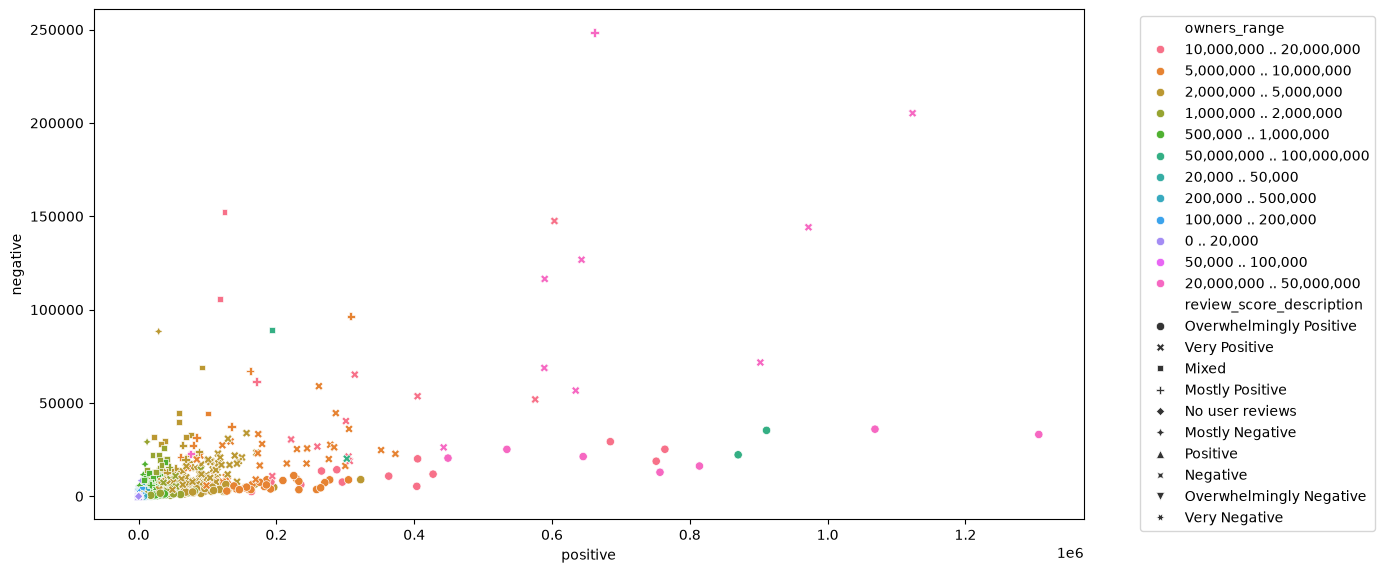

In [26]:
plt.figure(figsize=(14, 6))
sns.scatterplot(x=games['positive'], y=games['negative'], hue=games['owners_range'], style=games['review_score_description'])

plt.legend(
	bbox_to_anchor=(1.05, 1),
	loc='upper left'
)

plt.tight_layout()
plt.show()

Index(['prices_eur', 'review_score', 'positive', 'negative', 'total',
       'concurrent_users_yesterday', '10,000,000 .. 20,000,000',
       '5,000,000 .. 10,000,000', '2,000,000 .. 5,000,000',
       '1,000,000 .. 2,000,000', '500,000 .. 1,000,000',
       '50,000,000 .. 100,000,000', '20,000 .. 50,000', '200,000 .. 500,000',
       '100,000 .. 200,000', '0 .. 20,000', '50,000 .. 100,000',
       '20,000,000 .. 50,000,000', 'Overwhelmingly Positive', 'Very Positive',
       'Mixed', 'Mostly Positive', 'No user reviews', 'Mostly Negative',
       'Positive', 'Negative', 'Overwhelmingly Negative', 'Very Negative'],
      dtype='str')


<Axes: >

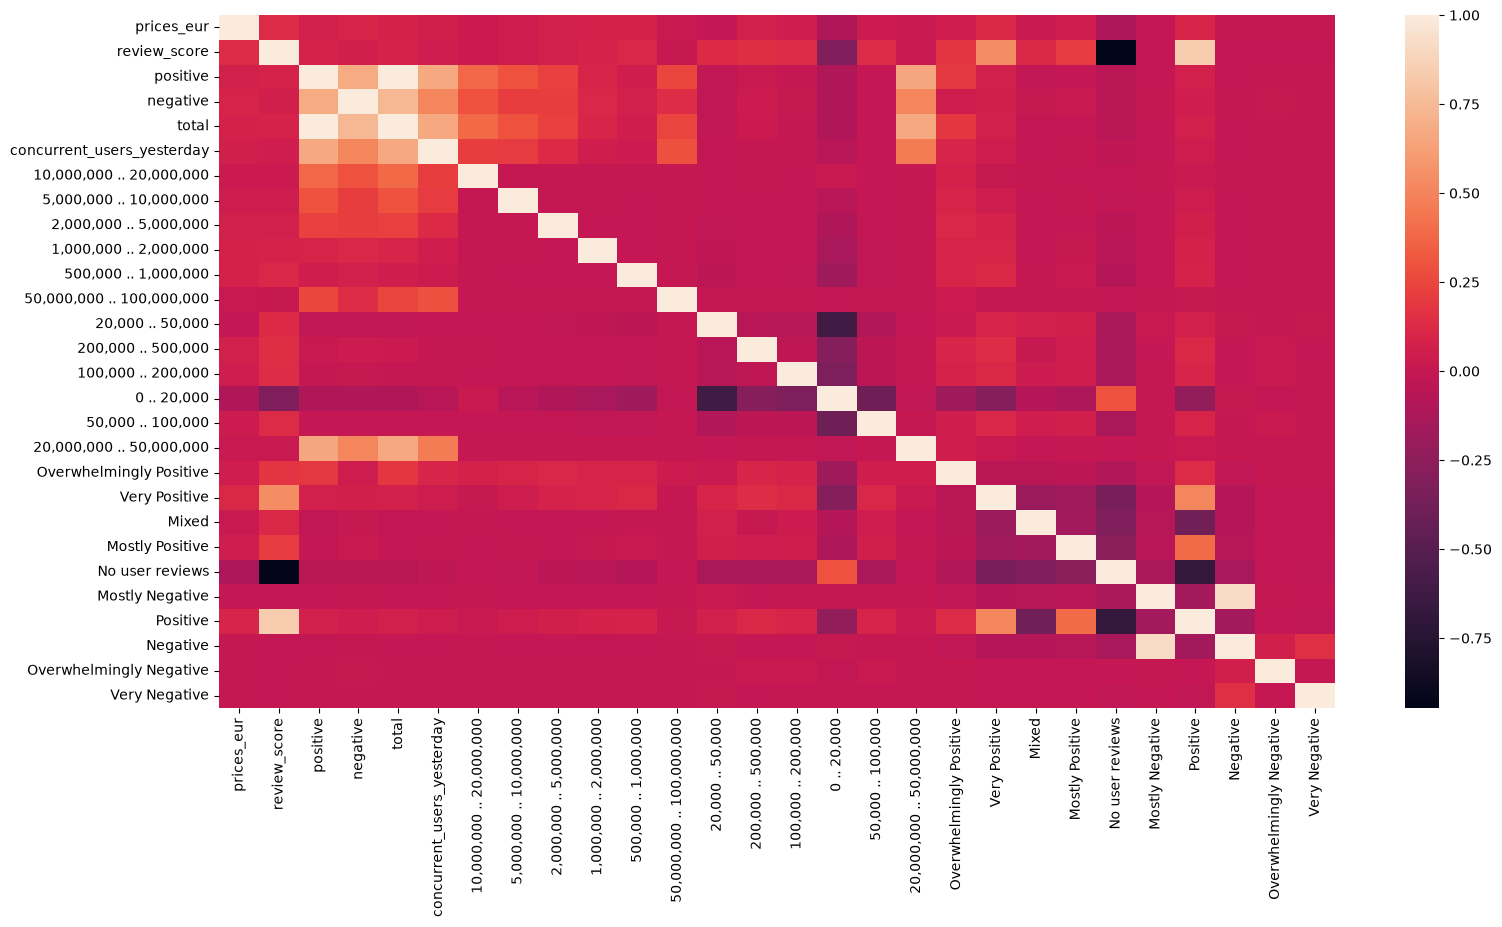

In [27]:
games_one_hot = one_hot_encoding(games, 'owners_range')
games_one_hot = one_hot_encoding(games_one_hot, 'review_score_description')
print(games_one_hot.columns[3:])
plt.figure(figsize=(18, 9))
games_one_hot[games_one_hot.columns[3:]]
correlation = games_one_hot[games_one_hot.columns[3:]].corr()
sns.heatmap(correlation)

In [28]:
def standardize_data(df):

	'''
	This function standardize an array, its substracts mean value,
	and then divide the standard deviation.

	param 1: array
	return: standardized array
	'''
	# Fórmula: (x - X_mean) / std
	mean = df.mean()
	std = df.std()
	new_df = (df - mean) / std

	return new_df, mean, std

In [29]:
# games_one_hot.info()
games_final = games_one_hot.drop(columns=['app_id', 'name', 'release_date'])

games_final = games_final.sample(frac=1)

# display(games_final)

df_x = games_final.iloc[:, [0, *range(2, len(games_final.columns))]]
df_y = games_final.iloc[:, 1]
# display(df_y)

train_length = round(len(df_x) * .8)
df_x_train = df_x[:train_length]
df_x_test = df_x[train_length:]

df_y_train = df_y[:train_length]
df_y_test = df_y[train_length:]

df_x_standar, mean, std = standardize_data(df_x_train.iloc[:, :5])
df_x_train = pd.concat([df_x_standar.iloc[:, :], df_x_train.iloc[:, 5:]], axis=1)
df_x_train

df_x_test_standar = (df_x_test.iloc[:, :5] - mean) / std
df_x_test = pd.concat([df_x_test_standar, df_x_test.iloc[:, 5:]], axis=1)
display(df_x_test)

see_nan_values(df_x_train)

,prices_eur,positive,negative,total,concurrent_users_yesterday,"10,000,000 .. 20,000,000","5,000,000 .. 10,000,000","2,000,000 .. 5,000,000","1,000,000 .. 2,000,000","500,000 .. 1,000,000",...,Overwhelmingly Positive,Very Positive,Mixed,Mostly Positive,No user reviews,Mostly Negative,Positive,Negative,Overwhelmingly Negative,Very Negative
7173,0.506327,-0.049137,-0.050219,-0.051073,-0.041124,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
13328,5.417937,-0.060295,-0.058088,-0.062227,-0.035182,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
69795,-0.038819,-0.068558,-0.069019,-0.071128,-0.041867,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
16127,0.31704,-0.068256,-0.065084,-0.070359,-0.041867,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
46159,-0.25082,-0.067050,-0.066396,-0.069425,-0.041867,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25112,0.127754,-0.067472,-0.065084,-0.069644,-0.041867,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
17971,-0.326534,-0.068136,-0.069019,-0.070743,-0.041867,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
36050,-0.25082,-0.067412,-0.069019,-0.070084,-0.041867,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
24827,-0.447678,-0.068558,-0.069019,-0.071128,-0.041867,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


<class 'pandas.DataFrame'>
Index: 61064 entries, 9937 to 26316
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   prices_eur                  61064 non-null  Float64
 1   positive                    61064 non-null  float64
 2   negative                    61064 non-null  float64
 3   total                       61064 non-null  float64
 4   concurrent_users_yesterday  61064 non-null  float64
 5   10,000,000 .. 20,000,000    61064 non-null  int64  
 6   5,000,000 .. 10,000,000     61064 non-null  int64  
 7   2,000,000 .. 5,000,000      61064 non-null  int64  
 8   1,000,000 .. 2,000,000      61064 non-null  int64  
 9   500,000 .. 1,000,000        61064 non-null  int64  
 10  50,000,000 .. 100,000,000   61064 non-null  int64  
 11  20,000 .. 50,000            61064 non-null  int64  
 12  200,000 .. 500,000          61064 non-null  int64  
 13  100,000 .. 200,000          61064 non-null  

In [30]:
# GET PCA to see tendencies 
covariance_matrix = np.cov(df_x.T.astype(float))

eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

# Calculating the explained variance on each of components
variance_explained = eigen_values / eigen_values.sum() * 100

# Identifying components that explain the relationship between the data
print("Varianza: ", variance_explained)
print("Verificar varianza: ", variance_explained.sum())

cumulative_variance_explained = np.cumsum(variance_explained)
print("Cumulative variance", cumulative_variance_explained)

projection_matrix = (eigen_vectors.T).T
projection_matrix

# Total -> 85.8% (PC_x = 78.07 + 7.78)
df_pca = df_x.dot(projection_matrix)
print(f"PC_X: {cumulative_variance_explained[0].real:.2f}% | PC_Y: {(cumulative_variance_explained[1].real - cumulative_variance_explained[0].real):.2f}%")

Varianza:  [ 9.92493100e+01+0.j  5.81943877e-01+0.j  1.68716384e-01+0.j
  2.95179671e-05+0.j  8.15722687e-08+0.j  3.95808539e-08+0.j
  3.18047350e-08+0.j  2.28774025e-08+0.j  1.27596995e-08+0.j
  1.06892253e-08+0.j  7.29079982e-09+0.j  6.95090256e-09+0.j
  5.15724091e-09+0.j  2.36921635e-09+0.j  1.81163153e-09+0.j
  1.21790359e-09+0.j  6.98919673e-10+0.j  4.74581028e-10+0.j
  2.02646278e-10+0.j  9.93046854e-11+0.j  5.78289251e-11+0.j
  1.52045689e-11+0.j  1.91916709e-11+0.j  6.71890615e-12+0.j
  4.15896898e-14+0.j -1.16376803e-24+0.j  1.31506697e-22+0.j]
Verificar varianza:  (100+0j)
Cumulative variance [ 99.24931   +0.j  99.83125387+0.j  99.99997026+0.j  99.99999977+0.j
  99.99999986+0.j  99.9999999 +0.j  99.99999993+0.j  99.99999995+0.j
  99.99999996+0.j  99.99999997+0.j  99.99999998+0.j  99.99999999+0.j
  99.99999999+0.j 100.        +0.j 100.        +0.j 100.        +0.j
 100.        +0.j 100.        +0.j 100.        +0.j 100.        +0.j
 100.        +0.j 100.        +0.j 100.     

c:\Users\Santiago\Documents\Personal\IA\Numpy\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:136: ComplexWarning: Casting complex values to real discards the imaginary part
  return arr.astype(dtype, copy=copy)
c:\Users\Santiago\Documents\Personal\IA\Numpy\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:136: ComplexWarning: Casting complex values to real discards the imaginary part
  return arr.astype(dtype, copy=copy)


<Axes: xlabel='0', ylabel='1'>

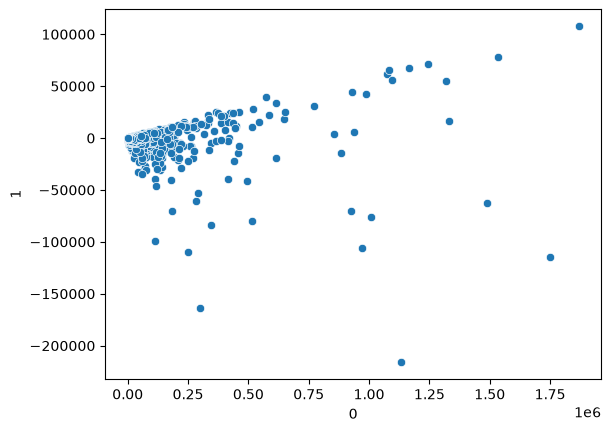

In [31]:
components = pd.DataFrame(df_pca)
components.head()

sns.scatterplot(x = components[0], y = components[1])

# Creación del modelo

Fórmula

$$ h(x) = mx+b $$

In [ ]:
def h(params, x_values, b):
	""" 
		Calcula el valor de h(x)
		Args:  
			params (array<float>): m_s
			x_values (array<float>): x_ij
			b (float): bias
		
		Returns:
			array<float>: función hipótesis
	"""
	return np.dot(x_values, params) + b

In [33]:
def calculate_loss(errors):
	return (errors ** 2).mean()

In [34]:
def huber_loss(y_pred, y, delta = 1.5):
  error = y - y_pred
  abs_error = np.abs(error)
    
    # Condición elemento a elemento:
    # Si abs(error) <= delta usa la pérdida cuadrática, si no, usa la lineal.
  return np.where(
		abs_error <= delta,
		0.5 * (error ** 2),
		delta * (abs_error - 0.5 * delta)
	).mean()

$$ \sum_{i=1}^n \left( h(x_i) - y_i  \right) x_{ij} $$

In [35]:
def sum(params, x_values, b, y, delta=1.5):
	"""sum

	Args:
		params (array<float>): m_s
		x_values (matrix<float>):  len(params) * len(instances)
		b (float)

	Returns:
		float: error total
	"""
	# Calcular error interno
	y_pred = h(params, x_values, b)
	errors = y_pred - y

	mean_error = huber_loss(y_pred, y)

	huber_gradient = np.where(
		np.abs(errors) <= delta,
		errors,
		delta * np.sign(errors)
	)

	# Calcular error acumulado
	theta_error = np.zeros(len(params) + 1)
	theta_error[:-1] = np.dot(huber_gradient, x_values)
	
	# Suma parámetro b
	theta_error[-1] = huber_gradient.sum()

	return theta_error, mean_error

$$ \theta_j = \theta_j - \frac{\alpha}{m} \sum_{i=1}^n \left( h(x_i) - y_i  \right) x_{ij} $$

In [36]:
def GD(params, alfa, b, x_values, y, change, momentum = 0.9):
	"""GD

	Args:
			params (_type_): _description_
			alfa (_type_): _description_
			b (_type_): _description_
			x_values (_type_): _description_
			y (_type_): _description_

	Returns:
			_type_: _description_
	"""
	# theta_length = len(params);
	m = 1 / len(x_values)
	
	future_params = params + momentum * change[:-1]
	future_b = b + momentum * change[-1]

	error_evaluation, mean_error = sum(future_params, x_values, future_b, y)
	
	change = (momentum * change) - alfa * m * error_evaluation
	new_params = params + change[:-1]
	b = b + change[-1]

	return new_params, b, change, mean_error

In [ ]:
def train(df_x, df_y, df_x_test, df_y_test):
	"""
		Entrenamiento del modelo
		Selecciona instancia
		Manda a llamar GD
	"""
	
	epochs = 0
	max_epochs = 3_000
	alfa = 0.4
	params = np.random.rand(len(df_x.columns)) * 100
	b = 0.5
	
	change = np.zeros(len(params)+1)
	momentum = 0.9
	
	errors = []
	test_errors = []
	
	while True:
		oldparams = params.copy()
		# print("Params: ", params)
  
		params, b, change, mean_error = GD(params, alfa, b, df_x, df_y, change, momentum)	
		errors.append(mean_error)

		# plt.plot(errors)
		test_predictions = h(params, df_x_test, b)
		# test_loss = calculate_loss(test_predictions - df_y_test)
		test_loss = huber_loss(test_predictions, df_y_test)
		test_errors.append(test_loss)
	
		if epochs % 100 == 0:
			print(f"Epoch {epochs}")
			print("Error: ", mean_error)
   
  
		epochs = epochs + 1	
		if epochs == max_epochs:
			print("Final epoch reached")
			print("final params: ")
			print(params)
			break
  
		if np.allclose(oldparams, params, atol=1e-6):
			print("Reached minimum")
			print("Epoch: ", epochs)
			print ("final params:")
			print (params)
			break
	return params, b, errors, test_errors

Epoch 0
Error:  241.7547079036849
Epoch 100
Error:  20.739936594818822
Epoch 200
Error:  4.688012591906193
Epoch 300
Error:  1.7950848049162038
Epoch 400
Error:  0.7560427092982434
Epoch 500
Error:  0.5116431944919106
Epoch 600
Error:  0.3408066018263277
Epoch 700
Error:  0.28007182673767766
Epoch 800
Error:  0.22621554221374363
Epoch 900
Error:  0.17544590914466526
Epoch 1000
Error:  0.16896523595638446
Epoch 1100
Error:  0.16666154983344264
Epoch 1200
Error:  0.16449853329815742
Epoch 1300
Error:  0.16235506484834075
Epoch 1400
Error:  0.16021454596315035
Epoch 1500
Error:  0.15807467438181183
Epoch 1600
Error:  0.15593512903378706
Epoch 1700
Error:  0.1537958638167025
Epoch 1800
Error:  0.15165687080905135
Epoch 1900
Error:  0.1495181473996746
Epoch 2000
Error:  0.14737969533240414
Epoch 2100
Error:  0.14524152906417187
Epoch 2200
Error:  0.1431036487289274
Epoch 2300
Error:  0.14096605232095843
Epoch 2400
Error:  0.13882873784893912
Epoch 2500
Error:  0.1366917033355591
Epoch 2600


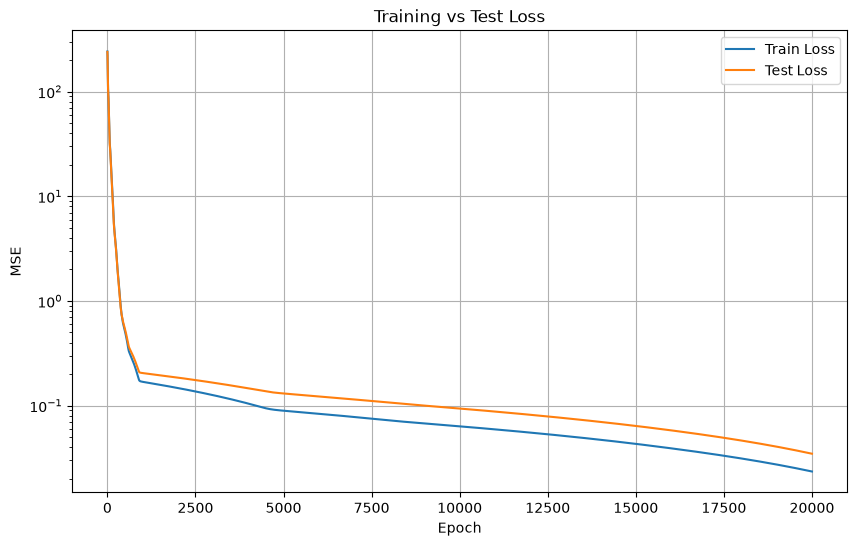

In [46]:
params, b, errors, test_errors = train(df_x_train, df_y_train, df_x_test, df_y_test)

plt.figure(figsize=(10, 6))

plt.plot(errors, label="Train Loss")
plt.plot(test_errors, label="Test Loss")

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Test Loss")

plt.legend()
plt.grid()

plt.show()

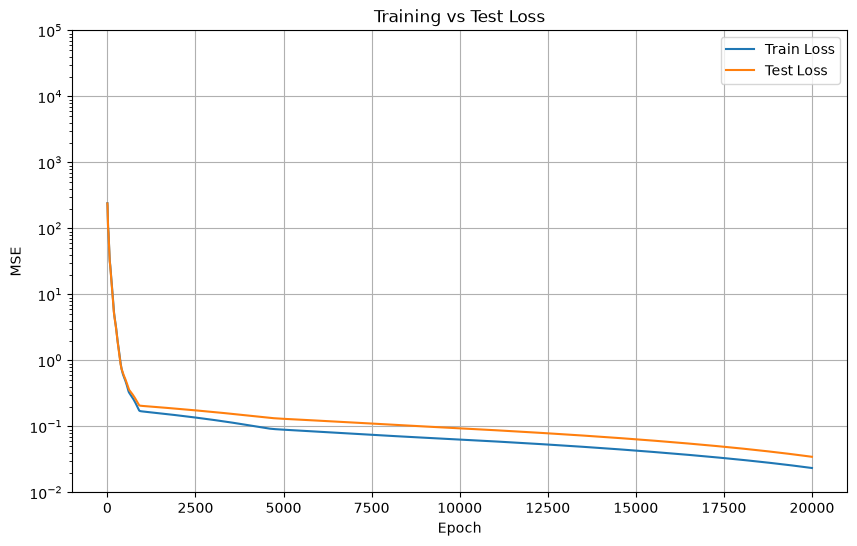

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(errors, label="Train Loss")
plt.plot(test_errors, label="Test Loss")

plt.yscale("log")
plt.ylim(1e-2, 1e5)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Test Loss")

plt.legend()
plt.grid()

plt.show()

In [48]:
df_x_train.columns

Index(['prices_eur', 'positive', 'negative', 'total',
       'concurrent_users_yesterday', '10,000,000 .. 20,000,000',
       '5,000,000 .. 10,000,000', '2,000,000 .. 5,000,000',
       '1,000,000 .. 2,000,000', '500,000 .. 1,000,000',
       '50,000,000 .. 100,000,000', '20,000 .. 50,000', '200,000 .. 500,000',
       '100,000 .. 200,000', '0 .. 20,000', '50,000 .. 100,000',
       '20,000,000 .. 50,000,000', 'Overwhelmingly Positive', 'Very Positive',
       'Mixed', 'Mostly Positive', 'No user reviews', 'Mostly Negative',
       'Positive', 'Negative', 'Overwhelmingly Negative', 'Very Negative'],
      dtype='str')

In [41]:
print(params, b)
display(df_x_test)
display(df_y_test)

[-7.04985107e-04 -1.36669552e+01 -1.89262359e+00  1.50240145e+01
  3.22058796e-03  3.39737754e+01  5.17185645e+01  5.18145896e+01
  5.18488599e+01  5.18565095e+01  9.63209133e+01  5.18582870e+01
  5.18587917e+01  5.18583823e+01  5.18588552e+01  5.18595428e+01
  4.55612966e+01  1.97594987e+00  9.98606447e-01  3.91714766e+01
 -9.99877308e-01  3.41716851e+01  1.27712368e+00  4.11716867e+01
  3.68949851e+01  8.85474339e+01  4.18550821e+00] -86.02947253070154


,prices_eur,positive,negative,total,concurrent_users_yesterday,"10,000,000 .. 20,000,000","5,000,000 .. 10,000,000","2,000,000 .. 5,000,000","1,000,000 .. 2,000,000","500,000 .. 1,000,000",...,Overwhelmingly Positive,Very Positive,Mixed,Mostly Positive,No user reviews,Mostly Negative,Positive,Negative,Overwhelmingly Negative,Very Negative
7173,0.506327,-0.049137,-0.050219,-0.051073,-0.041124,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
13328,5.417937,-0.060295,-0.058088,-0.062227,-0.035182,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
69795,-0.038819,-0.068558,-0.069019,-0.071128,-0.041867,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
16127,0.31704,-0.068256,-0.065084,-0.070359,-0.041867,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
46159,-0.25082,-0.067050,-0.066396,-0.069425,-0.041867,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25112,0.127754,-0.067472,-0.065084,-0.069644,-0.041867,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
17971,-0.326534,-0.068136,-0.069019,-0.070743,-0.041867,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
36050,-0.25082,-0.067412,-0.069019,-0.070084,-0.041867,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
24827,-0.447678,-0.068558,-0.069019,-0.071128,-0.041867,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


7173     8.0
13328    8.0
69795    0.0
16127    5.0
46159    7.0
        ... 
25112    5.0
17971    0.0
36050    7.0
24827    0.0
72794    0.0
Name: review_score, Length: 15266, dtype: float64

In [ ]:
train_predictions = h(params, df_x_train, b)
test_predictions = h(params, df_x_test, b)

print("Train loss MSE:", calculate_loss(train_predictions - df_y_train))
print("Test loss MSE:", calculate_loss(test_predictions - df_y_test))
print("\nTrain loss Huber:", huber_loss(train_predictions, df_y_train))
print("Test loss Huber:", huber_loss(test_predictions, df_y_test))

Train loss MSE: 0.20013643394667982
Test loss MSE: 0.24190467887404193

Train loss Huber: 0.027166814152485896
Test loss Huber: 0.028545450750228508


In [49]:
print(f"Tamaño test x: {len(df_x_test)}")
print(f"Tamaño test y: {len(df_y_test)}")

delta = 1.5

results = pd.DataFrame(data = np.dot(df_x_test, params) + b, columns=["Resultado"])
results["Esperado"] = df_y_test.reset_index(drop=True)

error_raw = results["Resultado"] - results["Esperado"]
results["Error MSE"] = error_raw**2
results["Error huber"] = np.where(
    error_raw.abs() <= delta,
    0.5 * (error_raw**2),
    delta * error_raw.abs() - 0.5 * delta**2,
)

display(results)

print(f"Max error MSE: {results["Error MSE"].max()}")
print(f"Mean error MSE: {results["Error MSE"].mean()}")
print(f"Mediana error MSE: {results["Error MSE"].median()}")
print(f"Min error MSE: {results["Error MSE"].min()}")
print(f"\nMax error Huber: {results["Error huber"].max()}")
print(f"Mean error Huber: {results["Error huber"].mean()}")
print(f"Mediana error Huber: {results["Error huber"].median()}")
print(f"Min error Huber: {results["Error huber"].min()}")

Tamaño test x: 15266
Tamaño test y: 15266


,Resultado,Esperado,Error MSE,Error huber
0,7.999962,8.0,0.0,0.0
1,8.001709,8.0,0.000003,0.000001
2,0.000172,0.0,0.0,0.0
3,5.000405,5.0,0.0,0.0
4,7.000151,7.0,0.0,0.0
...,...,...,...,...
15261,4.998403,5.0,0.000003,0.000001
15262,0.000117,0.0,0.0,0.0
15263,7.000153,7.0,0.0,0.0
15264,0.000097,0.0,0.0,0.0


Max error MSE: 1168.531812710378
Mean error MSE: 0.5532986103447977
Mediana error MSE: 7.245170674102352e-08
Min error MSE: 3.045834032510846e-14

Max error Huber: 50.150691888051114
Mean error Huber: 0.034748310058320846
Mediana error Huber: 3.622585337051176e-08
Min error Huber: 1.522917016255423e-14


In [44]:
import os
import json

with open("params_2.json", "w") as f:
  json.dump(params.tolist(), f)